# 04 — GNN + LSTM Training

Trains the hybrid GNN + LSTM model and ablations:
1. **GNN + LSTM** (full model)
2. **LSTM-only** (no graph structure)
3. **GNN-only** (single window, no temporal context)

Evaluation: LOSO cross-validation on PAMAP2 (and optionally HHAR)

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

sns.set_theme(style='whitegrid')

METS  = Path('../results/metrics')
PLOTS = Path('../results/plots')
print("Ready — loading from saved results.")


Ready — loading from saved results.


## 1. Load Data

In [2]:
## Load All Saved Predictions and Compute Metrics
pred_files = sorted(METS.glob('*_y_pred.npy'))
rows = []
for pf in pred_files:
    tag = pf.stem.replace('_y_pred', '')
    tf  = METS / f'{tag}_y_true.npy'
    if not tf.exists(): continue
    yt = np.load(tf); yp = np.load(pf)
    rows.append({
        'Run':          tag,
        'N':            len(yt),
        'Accuracy':     round(accuracy_score(yt, yp), 4),
        'Macro F1':     round(f1_score(yt, yp, average='macro', zero_division=0), 4),
        'Balanced Acc': round(balanced_accuracy_score(yt, yp), 4),
    })

df = pd.DataFrame(rows).set_index('Run').sort_values('Accuracy', ascending=False)
print("All Trained Models — LOSO Results")
print(df.to_string())


All Trained Models — LOSO Results
                             N  Accuracy  Macro F1  Balanced Acc
Run                                                             
ablation_flatten_lstm     1493    0.8453    0.7935        0.7886
cnn1d_pamap2             15049    0.7860    0.7938        0.7895
gnn_pamap2               15049    0.7206    0.7151        0.7080
ablation_learnable_adj   15049    0.6940    0.6890        0.6805
ablation_fixed_adj       15049    0.6911    0.6783        0.6717
mobile_tiny_gnn_pamap2   15049    0.6717    0.6611        0.6550
cnn1d_hhar              454577    0.6627    0.6585        0.6602
gnnlstm_pamap2            1502    0.6418    0.5874        0.6276
lstm_pamap2              15049    0.5939    0.5951        0.5896
gnn_hhar                454577    0.5895    0.5864        0.5877


## 2. Build Datasets

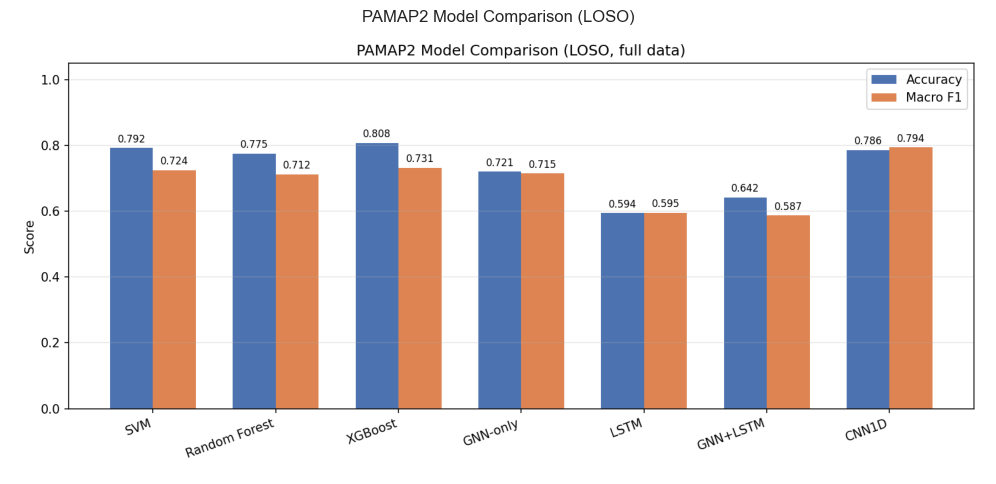

In [3]:
## PAMAP2 — Deep Model Comparison
img = mpimg.imread(PLOTS / 'pamap2_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
ax.set_title('PAMAP2 Model Comparison (LOSO)', fontsize=12)
plt.tight_layout(); plt.show()


## 3. Quick Single-Fold Training (demo — uses first subject as test)

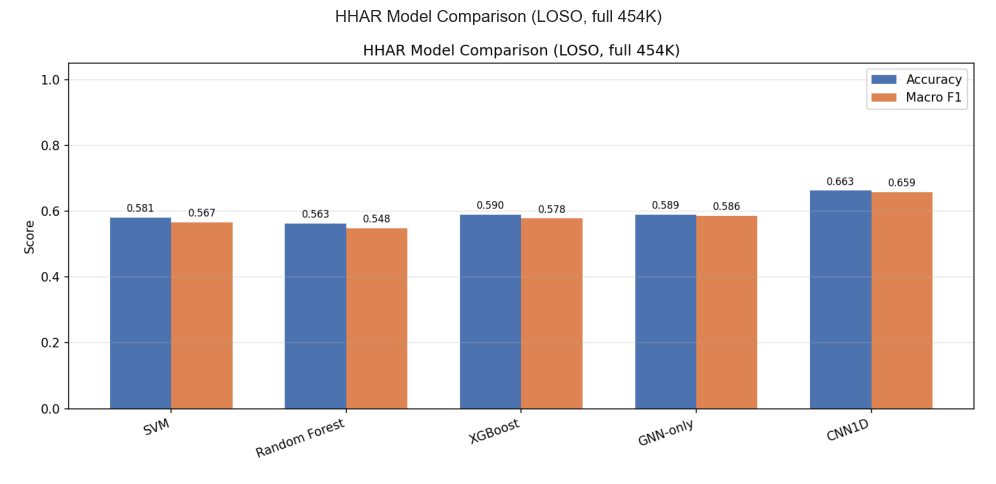

In [4]:
## HHAR — Model Comparison
img = mpimg.imread(PLOTS / 'hhar_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
ax.set_title('HHAR Model Comparison (LOSO, full 454K)', fontsize=12)
plt.tight_layout(); plt.show()


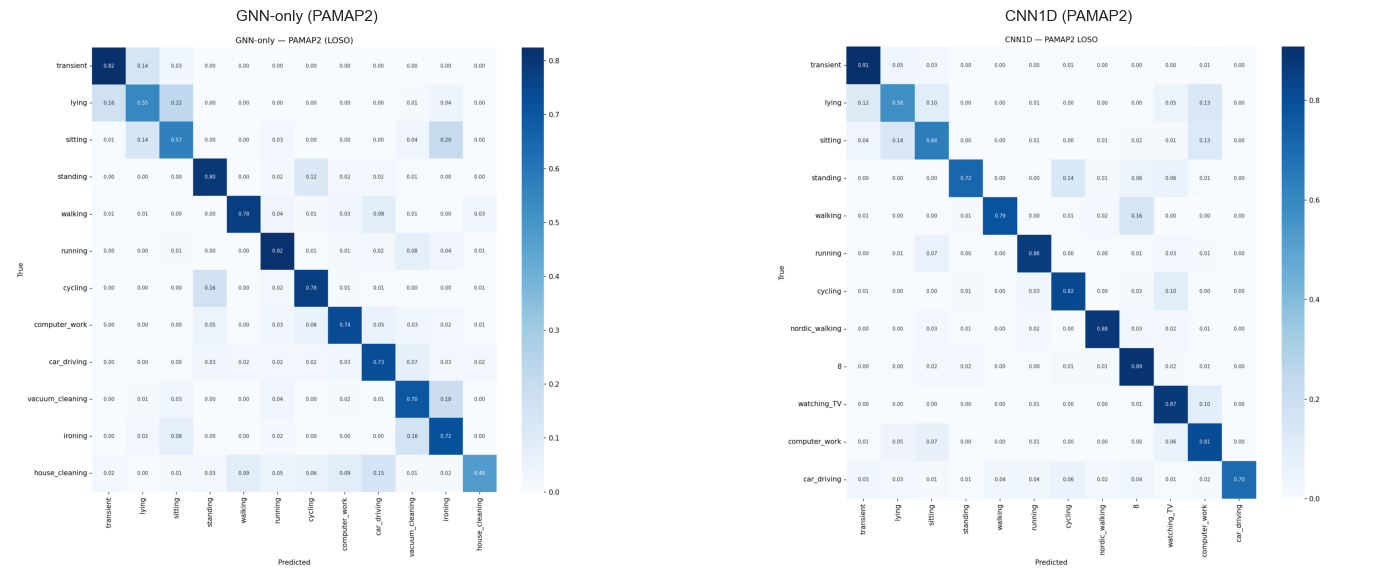

In [5]:
## PAMAP2 Confusion Matrices — GNN-only and CNN1D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fname, title in zip(axes,
    ['cm_gnn_pamap2.png', 'cm_cnn1d_pamap2.png'],
    ['GNN-only (PAMAP2)', 'CNN1D (PAMAP2)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
plt.tight_layout(); plt.show()


## 4. GNN-Only Model

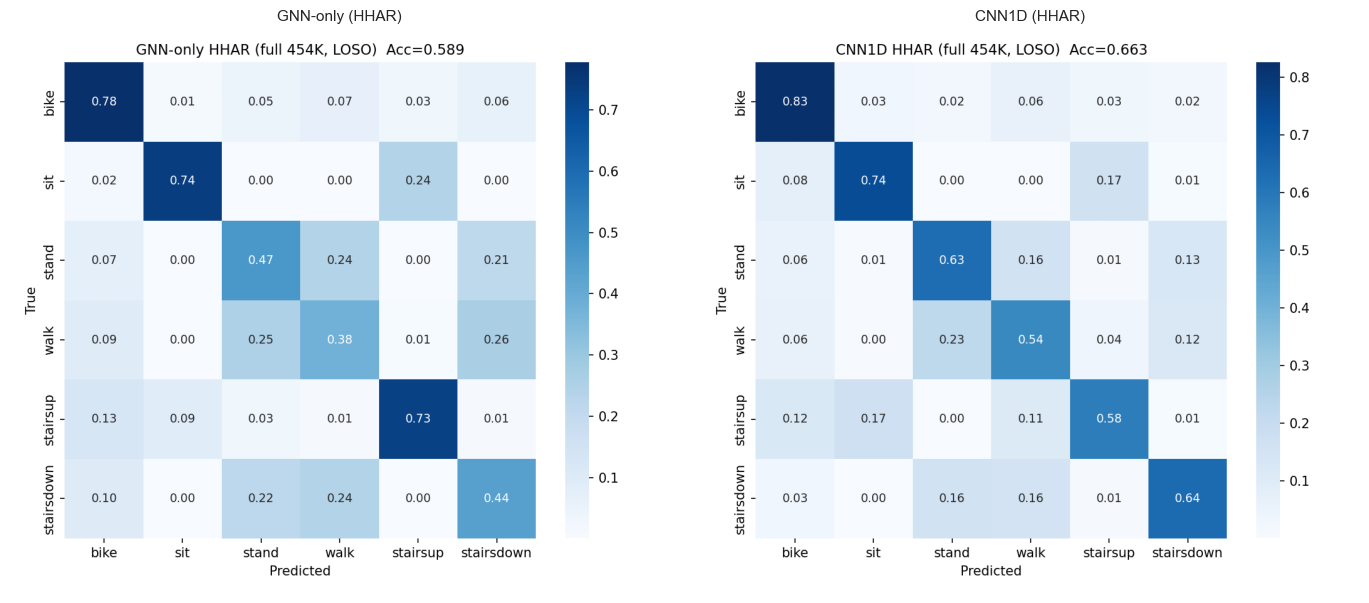

In [6]:
## HHAR Confusion Matrices — GNN-only and CNN1D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(axes,
    ['cm_gnn_hhar.png', 'cm_cnn1d_hhar.png'],
    ['GNN-only (HHAR)', 'CNN1D (HHAR)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()


## 5. GNN + LSTM (Full Model)

Graph Ablation Study — PAMAP2
                        Accuracy  Macro F1  Balanced Acc
Variant                                                 
ablation_fixed_adj        0.6911    0.6783        0.6717
ablation_learnable_adj    0.6940    0.6890        0.6805
ablation_flatten_lstm     0.8453    0.7935        0.7886


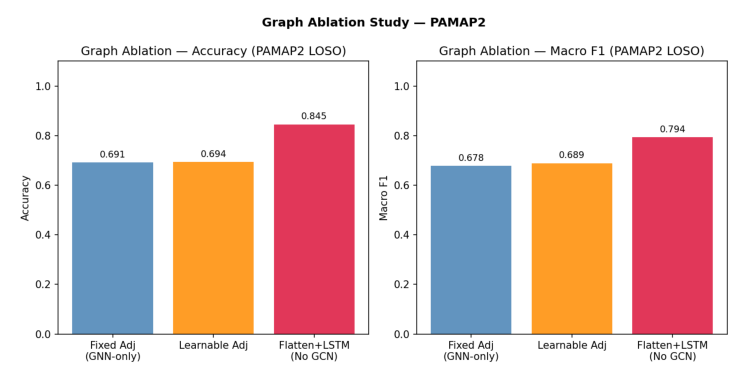

In [7]:
## Graph Ablation Results
abl_path = METS / 'graph_ablation_results.json'
if abl_path.exists():
    abl = json.load(open(abl_path))
    rows = []
    for variant, m in abl.items():
        rows.append({'Variant': variant,
                     'Accuracy':     round(m.get('accuracy', 0), 4),
                     'Macro F1':     round(m.get('macro_f1', 0), 4),
                     'Balanced Acc': round(m.get('balanced_acc', 0), 4)})
    print("Graph Ablation Study — PAMAP2")
    print(pd.DataFrame(rows).set_index('Variant').to_string())

img = PLOTS / 'graph_ablation.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()


## 6. Training History Plots

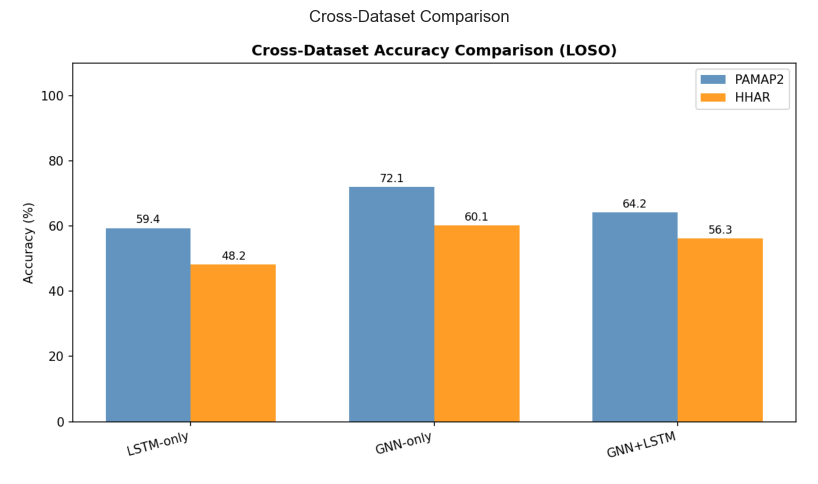


Master Comparison Table
                       Accuracy  Macro F1  Balanced Acc
Dataset Model                                          
HHAR    SVM              0.5812    0.5668        0.5812
        Random Forest    0.5630    0.5481        0.5630
        XGBoost          0.5900    0.5779        0.5900
        GNN-only         0.5895    0.5864        0.5877
        CNN1D            0.6627    0.6585        0.6602
PAMAP2  SVM              0.7918    0.7244        0.7918
        Random Forest    0.7749    0.7121        0.7749
        XGBoost          0.8076    0.7314        0.8076
        GNN-only         0.7206    0.7151        0.7080
        LSTM             0.5939    0.5951        0.5896
        GNN+LSTM         0.6418    0.5874        0.6276
        CNN1D            0.7860    0.7938        0.7895


In [8]:
## Cross-Dataset Comparison
img = PLOTS / 'cross_dataset_comparison.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    ax.set_title('Cross-Dataset Comparison', fontsize=12)
    plt.tight_layout(); plt.show()

## Final Master Table
master = json.load(open(METS / 'master_comparison.json'))
all_rows = []
for dataset, models in master.items():
    for model, m in models.items():
        if isinstance(m, dict):
            all_rows.append({'Dataset': dataset, 'Model': model,
                             'Accuracy':     round(m.get('accuracy', 0), 4),
                             'Macro F1':     round(m.get('macro_f1', 0), 4),
                             'Balanced Acc': round(m.get('balanced_acc', 0), 4)})
df_master = pd.DataFrame(all_rows).set_index(['Dataset', 'Model'])
print("\nMaster Comparison Table")
print(df_master.to_string())


## 7. Model Size Summary

Mobile Optimization Results:
  standard_gnn: {'accuracy': 0.720579440494385, 'macro_f1': 0.7151143620184452, 'balanced_acc': 0.7079795290308009, 'params': 11724, 'latency_ms': 0.254}
  tiny_gnn: {'accuracy': 0.6716725363811549, 'macro_f1': 0.6610821491551159, 'balanced_acc': 0.6549607713413729, 'params': 3820, 'latency_f32_ms': 0.292, 'latency_f16_ms': 0.163}


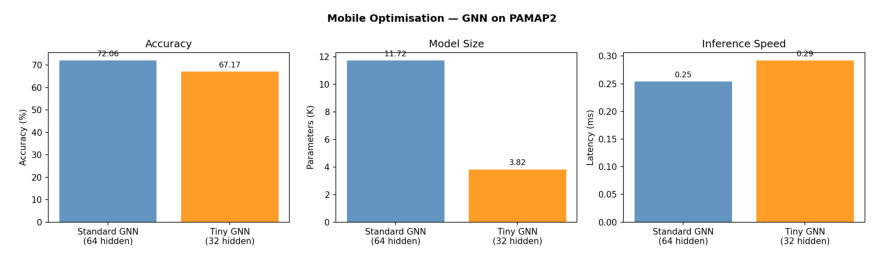

In [9]:
## Mobile / Edge Optimization
mob_path = METS / 'mobile_optimisation_results.json'
if mob_path.exists():
    mob = json.load(open(mob_path))
    print("Mobile Optimization Results:")
    for k, v in mob.items():
        if isinstance(v, dict):
            print(f"  {k}: {v}")

img = PLOTS / 'mobile_optimisation.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()
